Simulating Direct Coupling (K1=2.0, K2=0.09415459)...
✅ Stable. Max Amplitude: 58.33

--- Absolute Force Magnitudes ---
      Intrinsic  Pairwise  Triadic
Node                              
0         59.27     57.96    10.74
1         55.69     46.10    14.33
2         83.23     95.97    19.92
3         79.61     84.86    11.99
4         46.13     52.14    17.99
5         97.89    106.03    10.65
6         63.70     67.58    12.36
7         53.51     69.08    29.08
8         82.85    109.93    35.51
9         74.78     92.50    28.20


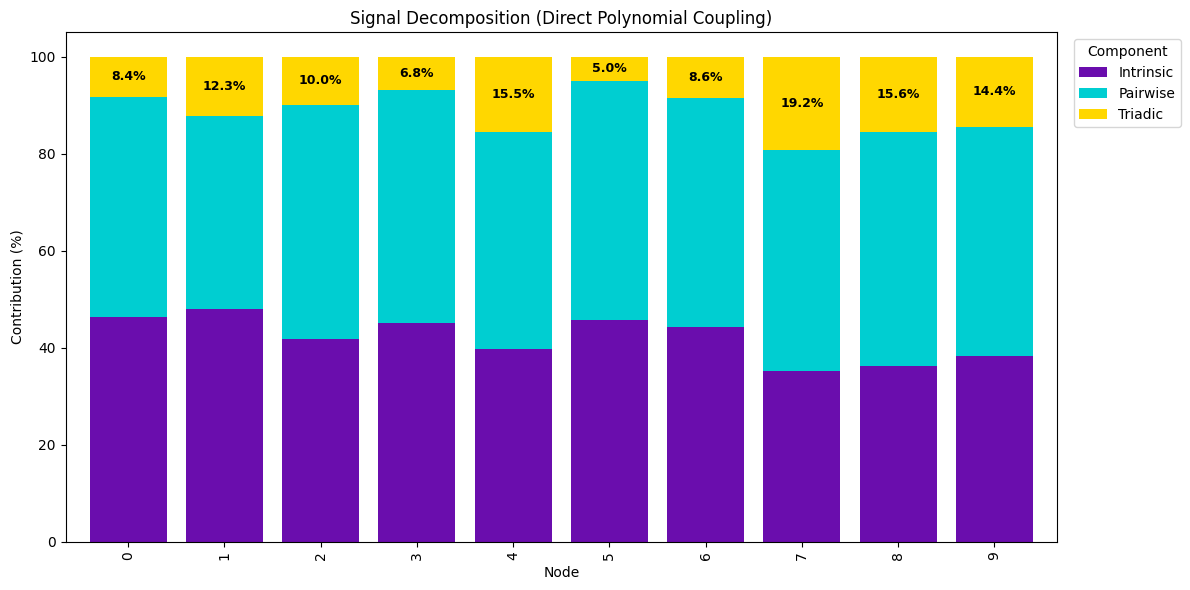

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETERS (New "Direct Coupling" Regime)
# ==========================================
# Standard Lorenz parameters for robust chaos
SIGMA = 10.0
BETA = 8.0 / 3.0

# Heterogeneity (Rho)
np.random.seed(42)
NUM_NODES = 10
RHO_VEC = np.random.uniform(28, 35, NUM_NODES)

# COUPLING (Direct Polynomial)
# Since we removed the (-x_i) damping part of the coupling,
# we lower K slightly to prevent energy runaway.
K1 = 2.0   # Coefficient for x_j
K2 = 0.09415459  # Coefficient for x_j * x_k (Quadratic grows fast, so keep small)

DT = 1 / 256.0
T_MAX = 20.0
TIME = np.arange(0, T_MAX, DT)

# ==========================================
# 2. TOPOLOGY
# ==========================================
EDGES = [
    (0, 1), (0, 2), (0, 3), (1, 2), (2, 3), (2, 8), (2, 9),
    (3, 4), (3, 5), (4, 5),
    (5, 6), (5, 8), (5, 9),
    (6, 7), (6, 8), (7, 8), (7, 9), (8, 9),
]
TRIANGLES = [
    (0, 1, 2), (7, 8, 9), (3, 4, 5), (6, 7, 8), (2, 8, 9)
]

adj_edges = {i: [] for i in range(NUM_NODES)}
for u, v in EDGES:
    adj_edges[u].append(v); adj_edges[v].append(u)

adj_triangles = {i: [] for i in range(NUM_NODES)}
for (u, v, w) in TRIANGLES:
    adj_triangles[u].append((v, w)); adj_triangles[v].append((u, w)); adj_triangles[w].append((u, v))

# ==========================================
# 3. DYNAMICS (The Modified Equation)
# ==========================================
def simplicial_lorenz_direct(state, t):
    s = state.reshape((NUM_NODES, 3))
    x = s[:, 0]; y = s[:, 1]; z = s[:, 2]

    dx = np.zeros(NUM_NODES)
    dy = np.zeros(NUM_NODES)
    dz = np.zeros(NUM_NODES)

    for i in range(NUM_NODES):
        # 1. Intrinsic
        term_int = SIGMA * (y[i] - x[i])

        # 2. Edge (Direct Sum of Neighbors)
        # Old: x[n] - x[i]  -> New: x[n]
        term_edge = 0.0
        for n in adj_edges[i]:
            term_edge += x[n]

        # 3. Triangle (Direct Product of Neighbors)
        # Old: (x[j]-x[i])(x[k]-x[i]) -> New: x[j] * x[k]
        term_tri = 0.0
        for (j, k) in adj_triangles[i]:
            term_tri += x[j] * x[k]

        dx[i] = term_int + (K1 * term_edge) + (K2 * term_tri)

        # y, z dynamics
        dy[i] = x[i] * (RHO_VEC[i] - z[i]) - y[i]
        dz[i] = x[i] * y[i] - BETA * z[i]

    return np.stack([dx, dy, dz], axis=1).flatten()

# Simulation
x0 = np.random.uniform(-5, 5, NUM_NODES)
y0 = np.random.uniform(-5, 5, NUM_NODES)
z0 = np.random.uniform(10, 25, NUM_NODES)
state0 = np.stack([x0, y0, z0], axis=1).flatten()

print(f"Simulating Direct Coupling (K1={K1}, K2={K2})...")
sol = odeint(simplicial_lorenz_direct, state0, TIME)

if np.any(np.isnan(sol)):
    print("❌ Explosion! Reduce K2.")
else:
    print(f"✅ Stable. Max Amplitude: {np.max(np.abs(sol)):.2f}")

    # Save Data for SINDy
    pd.DataFrame(sol).to_csv("simplicial_lorenz_FULL_30dim.csv", header=False, index=False)

    # ==========================================
    # 4. SIGNAL DECOMPOSITION ANALYSIS
    # ==========================================
    sol_reshaped = sol.reshape((-1, NUM_NODES, 3))
    X_data = sol_reshaped[:, :, 0]
    Y_data = sol_reshaped[:, :, 1]

    contributions = []
    for i in range(NUM_NODES):
        x_i = X_data[:, i]
        y_i = Y_data[:, i]

        # Intrinsic: |sigma(y-x)|
        f_intrinsic = np.mean(np.abs(SIGMA * (y_i - x_i)))

        # Pairwise: |K1 * sum(x_j)|
        term_pair = np.zeros_like(x_i)
        for n in adj_edges[i]:
            term_pair += K1 * X_data[:, n]
        f_pairwise = np.mean(np.abs(term_pair))

        # Triadic: |K2 * sum(x_j * x_k)|
        term_tri = np.zeros_like(x_i)
        for (j, k) in adj_triangles[i]:
            term_tri += K2 * X_data[:, j] * X_data[:, k]
        f_triadic = np.mean(np.abs(term_tri))

        contributions.append({
            "Node": i,
            "Intrinsic": f_intrinsic,
            "Pairwise": f_pairwise,
            "Triadic": f_triadic
        })

    df_c = pd.DataFrame(contributions).set_index("Node")
    df_pct = df_c.div(df_c.sum(axis=1), axis=0) * 100

    print("\n--- Absolute Force Magnitudes ---")
    print(df_c.round(2))

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    df_pct.plot(kind='bar', stacked=True, color=['#6a0dad', '#00ced1', '#ffd700'], width=0.8, ax=ax)

    for n in df_pct.index:
        y_base = df_pct.loc[n, 'Intrinsic'] + df_pct.loc[n, 'Pairwise']
        y_val = df_pct.loc[n, 'Triadic']
        if y_val > 1.0:
            ax.text(n, y_base + y_val/2, f"{y_val:.1f}%",
                    ha='center', va='center', fontsize=9, fontweight='bold')

    plt.title("Signal Decomposition (Direct Polynomial Coupling)")
    plt.ylabel("Contribution (%)")
    plt.legend(bbox_to_anchor=(1.01, 1), title="Component")
    plt.tight_layout()
    plt.show()

🚀 Starting Simulation...
✅ Data generated and saved to 'simplicial_lorenz_FULL_30dim.csv'


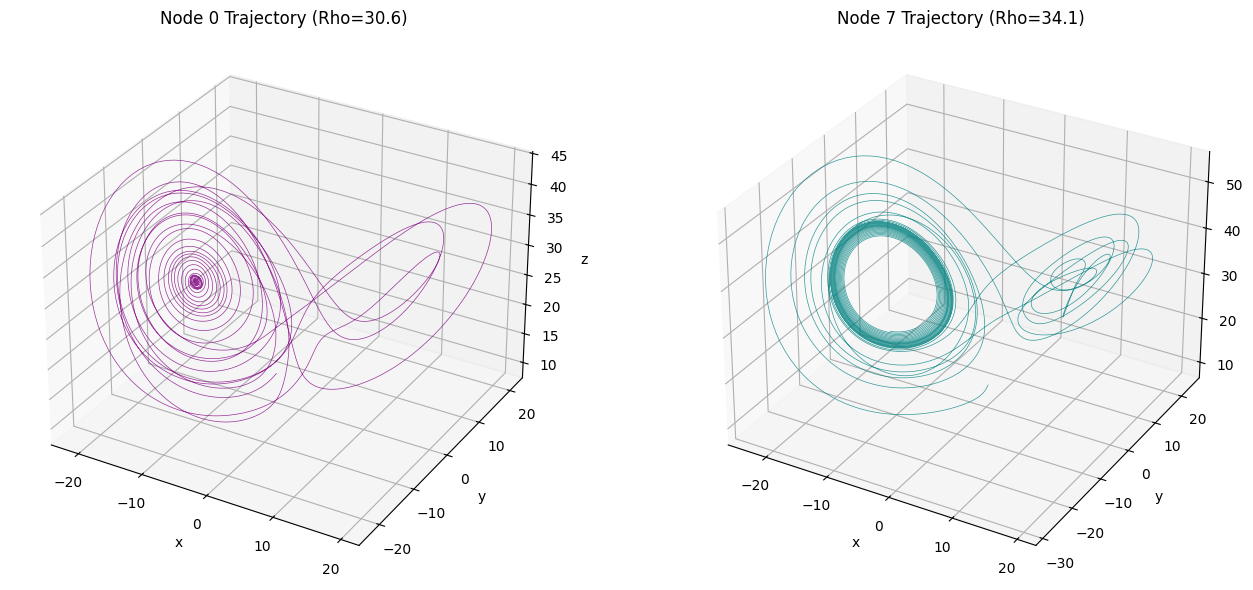

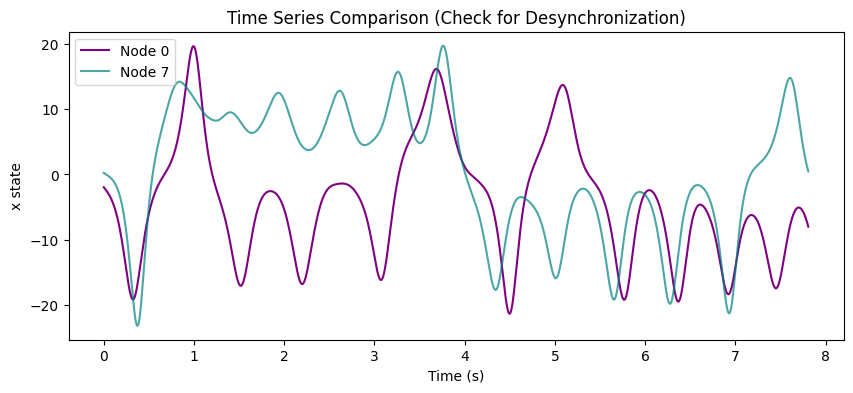

In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. SYSTEM CONFIGURATION
# ==========================================
SIGMA = 10.0
BETA = 8.0 / 3.0

# Heterogeneity: Randomized Rho to prevent synchronization
np.random.seed(42)
NUM_NODES = 10
RHO_VEC = np.random.uniform(28, 35, NUM_NODES)

# Direct Coupling Parameters
# K1: Linear Edge Strength
# K2: Quadratic Triangle Strength
K1 = 2.0
K2 = 0.09415459

# Time Settings
DT = 1 / 256.0
T_MAX = 20.0
TIME = np.arange(0, T_MAX, DT)

# ==========================================
# 2. TOPOLOGY DEFINITION
# ==========================================
EDGES = [
    (0, 1), (0, 2), (0, 3), (1, 2), (2, 3), (2, 8), (2, 9),
    (3, 4), (3, 5), (4, 5),
    (5, 6), (5, 8), (5, 9),
    (6, 7), (6, 8), (7, 8), (7, 9), (8, 9),
]

TRIANGLES = [
    (0, 1, 2),
    (7, 8, 9),
    (3, 4, 5),
    (6, 7, 8),
    (2, 8, 9),
]

# Build Adjacency Lists
adj_edges = {i: [] for i in range(NUM_NODES)}
for u, v in EDGES:
    adj_edges[u].append(v)
    adj_edges[v].append(u)

adj_triangles = {i: [] for i in range(NUM_NODES)}
for (u, v, w) in TRIANGLES:
    adj_triangles[u].append((v, w))
    adj_triangles[v].append((u, w))
    adj_triangles[w].append((u, v))

# ==========================================
# 3. DYNAMICS (Direct Coupling)
# ==========================================
def simplicial_lorenz_direct(state, t):
    # Reshape state to (Nodes, 3) for easier indexing
    s = state.reshape((NUM_NODES, 3))
    x = s[:, 0] # Array of all x values
    y = s[:, 1] # Array of all y values
    z = s[:, 2] # Array of all z values

    dx = np.zeros(NUM_NODES)
    dy = np.zeros(NUM_NODES)
    dz = np.zeros(NUM_NODES)

    for i in range(NUM_NODES):
        # --- A. Intrinsic Physics ---
        term_int = SIGMA * (y[i] - x[i])

        # --- B. Edge Coupling (Linear Sum) ---
        # "Direct" coupling: Sum(x_j) instead of Sum(x_j - x_i)
        # This separates the neighbor signal from the self-signal.
        term_edge = 0.0
        for n in adj_edges[i]:
            term_edge += x[n]

        # --- C. Triangle Coupling (Quadratic Product) ---
        # "Direct" coupling: Sum(x_j * x_k)
        term_tri = 0.0
        for (j, k) in adj_triangles[i]:
            term_tri += x[j] * x[k]

        # Combine Terms
        dx[i] = term_int + (K1 * term_edge) + (K2 * term_tri)

        # Y and Z dynamics (Standard Lorenz)
        dy[i] = x[i] * (RHO_VEC[i] - z[i]) - y[i]
        dz[i] = x[i] * y[i] - BETA * z[i]

    return np.stack([dx, dy, dz], axis=1).flatten()

# ==========================================
# 4. SIMULATION & PLOTTING
# ==========================================
print("🚀 Starting Simulation...")
# Initial Conditions (Random perturbation around origin)
x0 = np.random.uniform(-5, 5, NUM_NODES)
y0 = np.random.uniform(-5, 5, NUM_NODES)
z0 = np.random.uniform(10, 25, NUM_NODES)
state0 = np.stack([x0, y0, z0], axis=1).flatten()

# Integrate
sol = odeint(simplicial_lorenz_direct, state0, TIME)

# Reshape for analysis: (Time Steps, Nodes, 3 Variables)
data = sol.reshape((-1, NUM_NODES, 3))

# Save Data (for SINDy step later)
pd.DataFrame(sol).to_csv("simplicial_lorenz_FULL_30dim.csv", header=False, index=False)
print("✅ Data generated and saved to 'simplicial_lorenz_FULL_30dim.csv'")

# --- VISUALIZATION ---
fig = plt.figure(figsize=(14, 6))

# Plot 1: Node 0 Trajectory (Butterfly Shape)
ax1 = fig.add_subplot(121, projection='3d')
x_0, y_0, z_0 = data[:, 6, 0], data[:, 6, 1], data[:, 6, 2]
ax1.plot(x_0, y_0, z_0, lw=0.5, color='purple', alpha=0.8)
ax1.set_title(f"Node 0 Trajectory (Rho={RHO_VEC[0]:.1f})")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

# Plot 2: Node 7 Trajectory (Different Butterfly)
# Node 7 is in a triangle {7,8,9} and has high degree
ax2 = fig.add_subplot(122, projection='3d')
x_7, y_7, z_7 = data[:, 7, 0], data[:, 7, 1], data[:, 7, 2]
ax2.plot(x_7, y_7, z_7, lw=0.5, color='teal', alpha=0.8)
ax2.set_title(f"Node 7 Trajectory (Rho={RHO_VEC[7]:.1f})")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")

plt.tight_layout()
plt.show()

# Optional: Check synchronization
plt.figure(figsize=(10, 4))
plt.plot(TIME[:2000], x_0[:2000], label='Node 0', color='purple')
plt.plot(TIME[:2000], x_7[:2000], label='Node 7', color='teal', alpha=0.7)
plt.title("Time Series Comparison (Check for Desynchronization)")
plt.xlabel("Time (s)")
plt.ylabel("x state")
plt.legend()
plt.show()

In [ ]:
#!/usr/bin/env python3
# Full Simplicial SINDy pipeline +  2D GRID SEARCH over SIMPL_LAMBDA_SCALE and RHO
# The grid search calls the SAME pipeline (ADMM + SOC + flooring + pruning + debiasing)
# for each lambda scale, so its metrics are predictive of the real run.


import os
import math
import time
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✓ GPU (CuPy) detected")
    _ = cp.zeros(1)
except ImportError:
    GPU_AVAILABLE = False
    cp = np
    print("⚠️ GPU not available (using NumPy)")

xp = cp if GPU_AVAILABLE else np

# ----- Inline ground-truth (V2 Structure) -----
GT_EDGES_INLINE = {
    frozenset((0,1)), frozenset((0,2)), frozenset((0,3)), frozenset((1,2)),
    frozenset((2,3)), frozenset((2,8)), frozenset((2,9)),
    frozenset((3,4)), frozenset((3,5)), frozenset((4,5)),
    frozenset((5,6)), frozenset((5,8)), frozenset((5,9)),
    frozenset((6,7)), frozenset((7,8)), frozenset ((6,8)), frozenset((7,9)), frozenset((8,9)),
}
GT_TRIS_INLINE = {
    frozenset((0,1,2)),
    frozenset((3,4,5)), # Added for V2
    frozenset((7,8,9)), frozenset((6,7,8)), frozenset((2,8,9)),
}

# ---------- DIAGNOSTIC HELPERS ----------
def nnz_by_degree(Xi, maps, thr=1e-9):
    A = cp.asnumpy(Xi) if GPU_AVAILABLE else Xi
    nz = {"const": int(np.linalg.norm(A[0]) > thr)}
    nz["lin"]   = sum(int(np.linalg.norm(A[row]) > thr) for row in maps[1].values())
    nz["pairs"] = sum(int(np.linalg.norm(A[row]) > thr) for row in maps.get(2, {}).values())
    return nz

def gram_spectrum(G):
    Gh = cp.asnumpy(G) if GPU_AVAILABLE else G
    s = np.linalg.svd(Gh, compute_uv=False)
    return dict(smin=float(s[-1]), smax=float(s[0]), cond=float(s[0]/max(s[-1],1e-16)))

def kkt_grad_row_norms(G, B, Xi):
    R = G @ Xi - B
    return (cp.asnumpy(cp.linalg.norm(R, axis=1)) if GPU_AVAILABLE
            else np.linalg.norm(R, axis=1))

def sweep_triangle_thresholds(S3_scores, gt_tris_set, qs=np.linspace(0.5, 0.99, 11)):
    vals = np.array(list(S3_scores.values())) if S3_scores else np.array([])
    out = []
    for q in qs:
        if vals.size == 0:
            out.append({"q": float(q), "tau3": np.inf, "P":0,"R":0,"F1":0,"TP":0,"FP":0,"FN":len(gt_tris_set)})
            continue
        tau3 = float(np.quantile(vals, q))
        pred = {t for t, s in S3_scores.items() if s >= tau3}
        TP = len(pred & gt_tris_set)
        FP = len(pred - gt_tris_set)
        FN = len(gt_tris_set - pred)
        P  = TP / (TP + FP) if (TP+FP)>0 else 0.0
        R  = TP / (TP + FN) if (TP+FN)>0 else 0.0
        F1 = 2*P*R/(P+R) if (P+R)>0 else 0.0
        out.append({"q": float(q), "tau3": tau3, "P":P, "R":R, "F1":F1,
                    "TP":TP, "FP":FP, "FN":FN})
    return out

def per_degree_residuals(G, B, Xi, maps):
    A = Xi
    R_full = G @ A - B
    ls_full = 0.5 * float((R_full * R_full).sum())
    A_d2zero = A.copy()
    for row in maps.get(2, {}).values():
        A_d2zero[row, :] = 0.0
    R_d2zero = G @ A_d2zero - B
    ls_d2zero = 0.5 * float((R_d2zero * R_d2zero).sum())
    return dict(ls_full=ls_full, ls_no_pairs=ls_d2zero, delta_pairs=ls_d2zero - ls_full)

# ─────────────── PARAMETERS ───────────────────────────────
CSV_FILE = 'simplicial_lorenz_FULL_30dim.csv'

FS = 256.0
WIN_SG, ORDER = 29, 3
D_MAX = 2
SIMPL_RHO = 0.98
ADMM_RHO = 3.0
ADMM_OVERRELAX = 1.6
MAX_ITERS = 500       # we'll use this inside run_for_scale
WIN_LEN = 5120
STRIDE = WIN_LEN
MAX_ROWS = 6000
R_TARGET_PC = 0.95
K_MIN = 600
K_MAX = 1000000
ROW_NORM_NNZ_THR = 1e-6
PARAM_ABS_NNZ_THR = 1e-8
OUTDIR = 'dyn_complexes_admm_gpu_FULL_GRID'
os.makedirs(OUTDIR, exist_ok=True)
PAIR_LAMBDA_MULT = 1.0

# ─────────────── INDEX PATTERNS / TOPOLOGY ─────────────────
def precompute_index_patterns(n, dmax, use_xp=True):
    out = {}
    if dmax >= 2 and n >= 2:
        iu0, iu1 = np.triu_indices(n, k=1)
        pairs = np.stack([iu0.astype(np.int32), iu1.astype(np.int32)], axis=1)
        out['pairs'] = cp.asarray(pairs) if (use_xp and GPU_AVAILABLE) else pairs
    if dmax >= 3 and n >= 3:
        triples = np.array(list(combinations(range(n), 3)), dtype=np.int32)
        out['triples'] = cp.asarray(triples) if (use_xp and GPU_AVAILABLE) else triples
    if dmax >= 4 and n >= 4:
        quads = np.array(list(combinations(range(n), 4)), dtype=np.int32)
        out['quads'] = cp.asarray(quads) if (use_xp and GPU_AVAILABLE) else quads
    return out

def build_maps_from_patterns(n, dmax, idx):
    maps = {1:{}, 2:{}, 3:{}, 4:{}}
    row = 0
    if dmax >= 1:
        for i in range(n):
            row += 1
            maps[1][(i,)] = row
    if dmax >= 2 and 'pairs' in idx:
        for a, b in (idx['pairs'].get() if GPU_AVAILABLE else idx['pairs']):
            row += 1
            maps[2][(int(a), int(b))] = row
    if dmax >= 3 and 'triples' in idx:
        for i, j, k in (idx['triples'].get() if GPU_AVAILABLE else idx['triples']):
            row += 1
            maps[3][(int(i), int(j), int(k))] = row
    if dmax >= 4 and 'quads' in idx:
        for i, j, k, l in (idx['quads'].get() if GPU_AVAILABLE else idx['quads']):
            row += 1
            maps[4][(int(i), int(j), int(k), int(l))] = row
    g_total = row + 1   # include constant row 0
    return maps, g_total

def build_soc_edges_from_maps(dmax, maps):
    edges = []
    if dmax >= 2:
        for (i,j), child in maps[2].items():
            edges += [(child, maps[1][(i,)]), (child, maps[1][(j,)])]
    if dmax >= 3:
        for (i,j,k), child in maps[3].items():
            for face in combinations((i,j,k), 2):
                edges.append((child, maps[2][tuple(sorted(face))]))
    if dmax >= 4:
        for (i,j,k,l), child in maps[4].items():
            for face in combinations((i,j,k,l), 3):
                edges.append((child, maps[3][tuple(sorted(face))]))
    return edges

def build_library_fast(XT, n, dmax, idx):
    T = XT.shape[0]
    parts = [xp.ones((T, 1), dtype=XT.dtype)]  # constant term
    if dmax >= 1:
        parts.append(XT)
    if dmax >= 2 and 'pairs' in idx:
        p = idx['pairs']
        parts.append(XT[:, p[:, 0]] * XT[:, p[:, 1]])
    if dmax >= 3 and 'triples' in idx:
        tr = idx['triples']
        parts.append(XT[:, tr[:,0]] * XT[:, tr[:,1]] * XT[:, tr[:,2]])
    if dmax >= 4 and 'quads' in idx:
        qd = idx['quads']
        parts.append(XT[:, qd[:,0]] * XT[:, qd[:,1]] * XT[:, qd[:,2]] * XT[:, qd[:,3]])
    return xp.concatenate(parts, axis=1)

# ─────────────── GRAM PRECOMPUTE ───────────────────────────
def precompute_gram(Theta_std, Y_scaled):
    T = max(1, Theta_std.shape[0])
    G = (Theta_std.T @ Theta_std) / T
    eps_ridge = 5e-3
    G = G + eps_ridge * xp.eye(G.shape[0], dtype=G.dtype)
    B = (Theta_std.T @ Y_scaled)  / T
    return G, B

# ─────────────── SOC PROJECTION (exact) + DYKSTRA ───────────────────────────
def project_rows_dykstra(Z, edges, alpha, iters=25, tol=1e-7):
    Zc = Z.copy()
    if not edges:
        return Zc
    ci = xp.asarray([e[0] for e in edges], dtype=xp.int32)
    pi = xp.asarray([e[1] for e in edges], dtype=xp.int32)
    E, ncols = ci.shape[0], Zc.shape[1]
    inc_c = xp.zeros((E, ncols), dtype=Zc.dtype)
    inc_p = xp.zeros((E, ncols), dtype=Zc.dtype)
    for _ in range(iters):
        Zold = Zc.copy()
        c_tmp = Zc[ci] - inc_c
        p_tmp = Zc[pi] - inc_p
        C = xp.linalg.norm(c_tmp, axis=1)
        P = xp.linalg.norm(p_tmp, axis=1)
        feas = (C <= alpha * P + 1e-12)
        if (~feas).any():
            idx = xp.where(~feas)[0]
            Ct, Pt = C[idx], P[idx]
            cti, pti = c_tmp[idx], p_tmp[idx]
            denom = 1.0 + alpha * alpha
            t = (alpha * Ct + Pt) / denom
            sc = xp.where(Ct > 0, (alpha * t) / Ct, 0.0)
            sp = xp.where(Pt > 0, t / Pt, 0.0)
            c_tmp[idx] = cti * sc[:, None]
            p_tmp[idx] = pti * sp[:, None]
        inc_c = c_tmp - (Zc[ci] - inc_c)
        inc_p = p_tmp - (Zc[pi] - inc_p)
        Zc[ci] = c_tmp
        Zc[pi] = p_tmp
        if float(xp.linalg.norm(Zc - Zold)) < tol:
            break
    return Zc

# ─────────────── DEGREE-AWARE WEIGHTS ───────────────────────────
def degree_weights(maps, g):
    w = xp.ones(g, dtype=xp.float32)
    w[0] = 0.0   # constant row
    for (_,), r in maps.get(1, {}).items():
        w[r] *= xp.array(1.0, dtype=xp.float32)
    for (_,_), r in maps.get(2, {}).items():
        w[r] *= xp.array(PAIR_LAMBDA_MULT, dtype=xp.float32)
    return w

# ─────────────── ADMM SOLVER ─────────────────
def solve_admm_gl_soc(
    G, B, edges, lamb, rho_hier, w=None,
    max_iters=300, rho_admm=3.0, Xi0=None,
    log_every=25, adaptive_rho=True, overrelax=1.6,
    trace_every=1, return_trace=True, freeze_cholesky=False,
    early_proj_every=1, late_proj_every=1,
    early_proj_iters=15, late_proj_iters=50,
    early_proj_tol=1e-7,  late_proj_tol=1e-8,
    dtype_for_solves=None,
):
    """
    ADMM with:
      - group-lasso penalty (row-wise ℓ2)
      - SOC hierarchy constraints via Dykstra projection on rows
    Returns:
      (Xi, C)                if return_trace == False
      (Xi, C, trace_dict)    if return_trace == True
    """
    g, k = G.shape[0], B.shape[1]
    if w is None:
        w = xp.ones(g, dtype=G.dtype)

    # Optional dtype casting for stability
    if dtype_for_solves is not None and dtype_for_solves != G.dtype:
        Gs = G.astype(dtype_for_solves, copy=True)
        Bs = B.astype(dtype_for_solves, copy=True)
        Is = xp.eye(g, dtype=dtype_for_solves)
    else:
        Gs, Bs = G, B
        Is = xp.eye(g, dtype=G.dtype)

    # Variables
    Xi = xp.zeros((g, k), dtype=Gs.dtype) if Xi0 is None else Xi0.astype(Gs.dtype, copy=True)
    Z  = Xi.copy()
    C  = Xi.copy()
    Uz = xp.zeros_like(Xi)
    Uc = xp.zeros_like(Xi)

    # Linear system matrix
    A = Gs + (2.0 * rho_admm) * Is
    try:
        Lc = xp.linalg.cholesky(A)
        chol = True
    except Exception:
        chol = False

    # Should we actually record a trace?
    record_trace = (trace_every is not None) and (trace_every > 0) and return_trace

    trace = None
    if record_trace:
        trace = {
            "obj": [], "ls": [], "gl": [], "r_pri": [], "r_dual": [],
            "rho": [], "lam": [], "nnz_rows": [], "nnz_params": [],
            "soc_violations_before": [], "soc_violations_after": [], "cond_A": []
        }

    def count_soc_violations(M):
        if not edges:
            return 0
        ci = xp.asarray([e[0] for e in edges], dtype=xp.int32)
        pi = xp.asarray([e[1] for e in edges], dtype=xp.int32)
        cn = xp.linalg.norm(M[ci], axis=1)
        pn = xp.linalg.norm(M[pi], axis=1)
        return int((cn > rho_hier * pn + 1e-12).sum())

    def condition_number(A_mat):
        try:
            s = xp.linalg.svd(A_mat, compute_uv=False)
            return float(s[0] / max(s[-1], 1e-16))
        except Exception:
            return float("nan")

    if record_trace:
        trace["cond_A"].append(condition_number(A))

    lam = lamb

    for it in range(max_iters):
        Z_prev = Z.copy()
        C_prev = C.copy()

        # ---- Xi-step ----
        RHS = Bs + rho_admm * (Z - Uz + C - Uc)
        if chol and not freeze_cholesky:
            Y = xp.linalg.solve(Lc, RHS)
            Xi = xp.linalg.solve(Lc.T, Y)
        else:
            Xi = xp.linalg.solve(A, RHS)

        # Over-relaxation
        Xi_hat = overrelax * Xi + (1.0 - overrelax) * Z_prev

        # ---- Z-step: group lasso (row-wise shrinkage) ----
        Wz = Xi_hat + Uz
        norms = xp.sqrt((Wz * Wz).sum(axis=1) + 1e-16)
        shrink = xp.maximum(0.0, 1.0 - (lam * w) / (rho_admm * norms))
        Z = (Wz.T * shrink).T

        # ---- C-step: hierarchical SOC projection ----
        two_thirds = (2 * max_iters) // 3
        if it < two_thirds:
            proj_every = early_proj_every
            proj_iters = early_proj_iters
            proj_tol   = early_proj_tol
        else:
            proj_every = late_proj_every
            proj_iters = late_proj_iters
            proj_tol   = late_proj_tol

        soc_before = None
        if proj_every and (it % proj_every) == 0:
            if record_trace:
                soc_before = count_soc_violations(Xi_hat + Uc)
            C = project_rows_dykstra(Xi_hat + Uc, edges, rho_hier,
                                     iters=proj_iters, tol=proj_tol)
        else:
            C = Xi_hat + Uc

        soc_after = count_soc_violations(C) if record_trace else None

        # ---- Dual updates ----
        Uz += (Xi_hat - Z)
        Uc += (Xi_hat - C)

        # ---- Residuals ----
        r_pri = float(xp.linalg.norm(Xi - Z) + xp.linalg.norm(Xi - C))
        r_dual = float(rho_admm * xp.linalg.norm((Z - Z_prev) + (C - C_prev)))

        # ---- Trace bookkeeping ----
        if record_trace and (it % trace_every) == 0:
            R = Gs @ Xi - Bs
            ls = 0.5 * float(xp.sum(R * R))
            Z_row_norms = xp.sqrt((Z * Z).sum(axis=1) + 1e-16)
            gl = float(lam * xp.sum(w * Z_row_norms))

            trace["ls"].append(ls)
            trace["gl"].append(gl)
            trace["obj"].append(ls + gl)
            trace["r_pri"].append(r_pri)
            trace["r_dual"].append(r_dual)
            trace["rho"].append(rho_admm)
            trace["lam"].append(float(lam))
            nnz_rows = int((xp.linalg.norm(Z, axis=1) > ROW_NORM_NNZ_THR).sum())
            nnz_params = int((xp.abs(Z) > PARAM_ABS_NNZ_THR).sum())
            trace["nnz_rows"].append(nnz_rows)
            trace["nnz_params"].append(nnz_params)
            trace["soc_violations_before"].append(int(soc_before) if soc_before is not None else None)
            trace["soc_violations_after"].append(int(soc_after) if soc_after is not None else None)

        # ---- Optional logging (for the "full run") ----
        if log_every and ((it % log_every) == 0 or it == max_iters - 1):
            # If we didn't just compute ls/gl, recompute quickly
            if not (record_trace and trace_every and (it % trace_every) == 0):
                R = Gs @ Xi - Bs
                ls = 0.5 * float(xp.sum(R * R))
                gl = float(lam * xp.sum(w * xp.sqrt((Z * Z).sum(axis=1) + 1e-16)))
            nnz_rows = int((xp.linalg.norm(Z, axis=1) > ROW_NORM_NNZ_THR).sum())
            print(
                f"    ADMM it={it:3d} | ls={ls:.3e} gl={gl:.3e} "
                f"| obj={ls+gl:.3e} | r_pri={r_pri:.2e} r_dual={r_dual:.2e} ρ={rho_admm:.2g} "
                f"| nnz_rows={nnz_rows}"
            )

        # ---- Adaptive ρ ----
        if adaptive_rho and it % 5 == 0 and it > 20:
            ratio = r_pri / max(r_dual, 1e-12)
            if ratio > 1.8:
                rho_admm *= 1.25
                Uz /= 1.25
                Uc /= 1.25
            elif ratio < 0.55:
                rho_admm /= 1.25
                Uz *= 1.25
                Uc *= 1.25
            rho_admm = float(min(max(rho_admm, 2.0), 10.0))
            A = Gs + (2.0 * rho_admm) * Is
            if not freeze_cholesky:
                try:
                    Lc = xp.linalg.cholesky(A)
                    chol = True
                except Exception:
                    chol = False
            if record_trace:
                trace["cond_A"].append(condition_number(A))

        # ---- Convergence test ----
        if r_pri < 1e-3 and r_dual < 1e-3:
            break

    if return_trace:
        return Xi, C, trace
    else:
        return Xi, C



# ─────────────── READ-OUT (S2/S3/S4) ───────────────────────────
def readout_scores_multi_mode(Xi, n, dmax, maps):
    """
    Returns S2 (edges) and THREE variants of S3 (triangles):
      - S3_max:  max(w_i, w_j, w_k)  (Most lenient, best for recall)
      - S3_mean: mean(w_i, w_j, w_k) (Balanced)
      - S3_geom: geom(w_i, w_j, w_k) (Strict, requires symmetry)
    """
    A = cp.asnumpy(Xi) if GPU_AVAILABLE else Xi
    absA = np.abs(A)
    out = {}

    # ----- S2: edge scores (Unchanged, max is standard for edges) -----
    if dmax >= 1 and maps[1]:
        S2_dir = np.zeros((n, n))
        for j in range(n):
            row = maps[1][(j,)]
            for i in range(n):
                if i == j: continue
                S2_dir[i, j] = absA[row, i]
        out['S2'] = np.maximum(S2_dir, S2_dir.T)

    # ----- S3: Multi-mode triangle scores -----
    if dmax >= 2 and maps[2]:
        S3_max = {}
        S3_mean = {}
        S3_geom = {}

        pair_row = maps[2]
        for i in range(n):
            for j in range(i + 1, n):
                for k in range(j + 1, n):
                    tri = frozenset((i, j, k))

                    # Get row indices for pairs (j,k), (i,k), (i,j)
                    r_jk = pair_row.get(tuple(sorted((j, k))))
                    r_ik = pair_row.get(tuple(sorted((i, k))))
                    r_ij = pair_row.get(tuple(sorted((i, j))))

                    if (r_jk is None) or (r_ik is None) or (r_ij is None):
                        continue

                    # Extract weights from the three equations
                    # w_i is the coeff of x_j*x_k in equation i
                    w_i = absA[r_jk, i]
                    w_j = absA[r_ik, j]
                    w_k = absA[r_ij, k]

                    weights = [w_i, w_j, w_k]

                    # 1. Max (Lenient)
                    s_max = max(weights)
                    if s_max > 1e-9: S3_max[tri] = s_max

                    # 2. Arithmetic Mean (Balanced)
                    s_mean = sum(weights) / 3.0
                    if s_mean > 1e-9: S3_mean[tri] = s_mean

                    # 3. Geometric Mean (Strict - Current)
                    s_geom = (w_i * w_j * w_k) ** (1.0/3.0)
                    if s_geom > 1e-9: S3_geom[tri] = s_geom

        out['S3_max'] = S3_max
        out['S3_mean'] = S3_mean
        out['S3_geom'] = S3_geom

    return out

# ─────────────── EDGE THRESHOLD SWEEP ───────────────────────
def sweep_edge_thresholds(S2, gt_edges_set, qs=np.linspace(0.30, 0.99, 15)):
    nloc = S2.shape[0]
    vals = [S2[i, j] for i in range(nloc) for j in range(i+1, nloc) if S2[i, j] > 0]
    out = []
    if not vals:
        return out
    for q in qs:
        tau2 = float(np.quantile(vals, q))
        pred = {frozenset((i, j)) for i in range(nloc) for j in range(i+1, nloc) if S2[i, j] >= tau2}
        TP = len(pred & gt_edges_set)
        FP = len(pred - gt_edges_set)
        FN = len(gt_edges_set - pred)
        P  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        R  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        F1 = 2*P*R/(P+R) if (P+R) > 0 else 0.0
        out.append({"q": q, "tau2": tau2, "P": P, "R": R, "F1": F1})
    return out

# ─────────────── DATA LOADING & PREPROCESS ───────────────────────
print("\n📂 Loading data...")
if not os.path.exists(CSV_FILE):
    print(f"❌ Error: Data file '{CSV_FILE}' not found.")
    raise SystemExit(1)

# --- NEW: Lorenz-aware parsing for 30D CSV ---
# --- NEW: Lorenz-aware parsing for 30D CSV + intrinsic subtraction ---
raw_mat = pd.read_csv(CSV_FILE, header=None).values.astype(np.float64)
# raw_mat shape: (T, 3*NUM_NODES)
T_raw, D = raw_mat.shape
assert D == 3 * NUM_NODES, f"Expected {3*NUM_NODES} columns, got {D}"

# reshape to (T, N, 3)
sol = raw_mat.reshape(T_raw, NUM_NODES, 3)

# extract x, y, z -> each shape (N, T)
x_raw = sol[:, :, 0].T
y_raw = sol[:, :, 1].T
z_raw = sol[:, :, 2].T

# optional: drop degenerate x channels (shouldn't happen for Lorenz, but keeps your old logic)
mask = np.ptp(x_raw, axis=1) > 1e-12
x_raw = x_raw[mask]
y_raw = y_raw[mask]
z_raw = z_raw[mask]

n, T_raw = x_raw.shape
dt = 1 / FS
print(f"✓ Using X,Y,Z: {n} nodes × {T_raw} samples ({T_raw/FS:.1f}s)")

half = (WIN_SG - 1) // 2

# Smooth x, y, z with the SAME Savitzky–Golay settings
X_smooth = savgol_filter(x_raw, WIN_SG, ORDER, axis=1, mode='interp')[:, half:-half]
Y_smooth = savgol_filter(y_raw, WIN_SG, ORDER, axis=1, mode='interp')[:, half:-half]
Z_smooth = savgol_filter(z_raw, WIN_SG, ORDER, axis=1, mode='interp')[:, half:-half]  # not strictly needed, but nice to have

# Total derivative of x (what you were using before)
dXdt_raw = savgol_filter(
    x_raw, WIN_SG, ORDER, deriv=1, delta=dt, axis=1, mode='interp'
)[:, half:-half]

# Per-node mean/std for X (same as before — we standardize x only)
mu  = X_smooth.mean(axis=1, keepdims=True)
sig = X_smooth.std(axis=1, keepdims=True) + 1e-8

# Standardized state used for library
X = (X_smooth - mu) / sig

# ---- NEW: intrinsic Lorenz term and coupling residual ----
# intrinsic: σ (y_i - x_i) evaluated on the smoothed trajectories
dx_intrinsic = SIGMA * (Y_smooth - X_smooth)

# target for SINDy: "coupling only"
Y = (dXdt_raw - dx_intrinsic) / sig

print("✓ Built coupling-only target: dX - σ(y - x)")
print(f"  mean |intrinsic|: {np.mean(np.abs(dx_intrinsic)):.3f}")
print(f"  mean |coupling| : {np.mean(np.abs(dXdt_raw - dx_intrinsic)):.3f}")


X_gpu = cp.asarray(X) if GPU_AVAILABLE else X
Y_gpu = cp.asarray(Y) if GPU_AVAILABLE else Y
print(f"✓ Data on {'GPU' if GPU_AVAILABLE else 'CPU'}")

# ─────────────── WINDOW SELECTION (single full window) ───────────────
print("\n🔍 Preparing single full-length window...")
def select_local(Xw):
    x0 = np.median(Xw, axis=1, keepdims=True)
    Xc = Xw - x0
    sigma = np.maximum(
        1e-8,
        1.4826 * np.median(
            np.abs(Xc - np.median(Xc, axis=1, keepdims=True)),
            axis=1, keepdims=True
        )
    )
    d_pc = np.sqrt(((Xc / sigma) ** 2).sum(axis=0)) / np.sqrt(Xc.shape[0])
    keep = np.where(d_pc <= R_TARGET_PC)[0]
    if keep.size < K_MIN:
        keep = np.argsort(d_pc)[:K_MIN]
    elif keep.size > K_MAX:
        keep = np.argsort(d_pc)[:K_MAX]
    return x0, np.sort(keep), d_pc

w_start = 0
w_end   = WIN_LEN
Xw_full = X[:, w_start:w_end]
x0_full, keep_full, d_pc_full = select_local(Xw_full)
metas = [{
    "w_start": w_start,
    "t_mid": (w_start + WIN_LEN / 2) * dt,
    "x0": x0_full.flatten(),
    "keep": keep_full
}]
print("✓ 1 window ready (entire dataset)")

# ─────────────── PRECOMPUTE TOPOLOGY ───────────────────────
print("\n⚙️  Precomputing topology (maps/edges) once...")
idx_patterns = precompute_index_patterns(n, D_MAX, use_xp=True)
maps0, g_total = build_maps_from_patterns(n, D_MAX, idx_patterns)
edges0 = build_soc_edges_from_maps(D_MAX, maps0)
print(f"✓ g_total={g_total} rows | edges={len(edges0)} (dmax={D_MAX})")

w_degree_base = degree_weights(maps0, g_total)

# ─────────────── BUILD LIBRARY, GRAM, STATS (once) ───────────────────────
# We use the single window meta
meta = metas[0]
w_start, w_end = meta["w_start"], meta["w_start"] + WIN_LEN

if GPU_AVAILABLE:
    Xw = X_gpu[:, w_start:w_end]
    Yw = Y_gpu[:, w_start:w_end]
    x0 = cp.asarray(meta["x0"].reshape(-1, 1))
    Xw_c = Xw - x0
    Xw_use = Xw_c[:, meta["keep"]]
    Yw_use = Yw[:, meta["keep"]]
    if Xw_use.shape[1] > MAX_ROWS:
        idx = cp.linspace(0, Xw_use.shape[1] - 1, MAX_ROWS, dtype=cp.int32)
        Xw_use = Xw_use[:, idx]
        Yw_use = Yw_use[:, idx]
    XT = Xw_use.T
    YT = Yw_use.T
else:
    Xw = X[:, w_start:w_end]
    Yw = Y[:, w_start:w_end]
    x0 = meta["x0"].reshape(-1, 1)
    Xw_c = Xw - x0
    Xw_use = Xw_c[:, meta["keep"]]
    Yw_use = Yw[:, meta["keep"]]
    if Xw_use.shape[1] > MAX_ROWS:
        idx = np.linspace(0, Xw_use.shape[1] - 1, MAX_ROWS, dtype=int)
        Xw_use = Xw_use[:, idx]
        Yw_use = Yw_use[:, idx]
    XT = Xw_use.T
    YT = Yw_use.T

Theta = build_library_fast(XT, n, D_MAX, idx_patterns)

Theta_mean = xp.mean(Theta, axis=0, keepdims=True)
Theta_stdv = xp.std(Theta, axis=0, keepdims=True) + 1e-8
Thetaz = (Theta - Theta_mean) / Theta_stdv

Y_mean = xp.mean(YT, axis=0, keepdims=True)
Y_stdv = xp.std(YT, axis=0, keepdims=True) + 1e-8
Y_scaled = (YT - Y_mean) / Y_stdv

Thetaz   = Thetaz.astype(xp.float32, copy=False)
Y_scaled = Y_scaled.astype(xp.float32, copy=False)
G, B = precompute_gram(Thetaz, Y_scaled)

# Stats needed for lambda
T_eff = Thetaz.shape[0]
G_eff = Thetaz.shape[1]

if GPU_AVAILABLE:
    med = cp.median(Y_scaled, axis=0, keepdims=True)
    mad = cp.median(cp.abs(Y_scaled - med), axis=0, keepdims=True)
    res_std = float(1.4826 * cp.mean(mad))
else:
    med = np.median(Y_scaled, axis=0, keepdims=True)
    mad = np.median(np.abs(Y_scaled - med), axis=0, keepdims=True)
    res_std = 1.4826 * float(np.mean(mad))

# Fix 2: per-row weights from feature std
col_std = xp.std(Thetaz, axis=0).astype(xp.float32)
w_rows = xp.ones(G.shape[0], dtype=xp.float32)
bad = (col_std < 1e-6)
if (cp.any(bad).item() if GPU_AVAILABLE else bool(np.any(bad))):
    w_rows = w_rows.copy()
    w_rows[bad] = xp.array(3.0, dtype=w_rows.dtype)

gt_edges_set = GT_EDGES_INLINE
gt_tris_set  = GT_TRIS_INLINE

# ─────────────── SINGLE-SCALE FULL PIPELINE WRAPPER ───────────────────────
def run_for_scale(scale, rho_val, verbose=False):
    """
    Run the FULL pipeline with DYNAMIC RHO and Multi-Metric Readout.
    """
    # 1. Compute lambda
    lam = scale * (res_std / max(1, math.sqrt(T_eff))) * math.sqrt(2.0 * math.log(max(2, G_eff)))

    # 2. ADMM solve (Inject rho_val)
    w = (w_degree_base.astype(xp.float32) * w_rows).astype(xp.float32)

    Xi_gpu, C_gpu = solve_admm_gl_soc(
        G, B, edges0, lamb=lam,
        rho_hier=rho_val,   # <--- DYNAMIC RHO
        w=w, max_iters=MAX_ITERS, rho_admm=ADMM_RHO,
        Xi0=None, log_every=0, adaptive_rho=True, overrelax=ADMM_OVERRELAX,
        trace_every=0, return_trace=False
    )

    # 3. Final SOC projection (Inject rho_val)
    Xi_gpu = project_rows_dykstra(C_gpu, edges0, rho_val, iters=200, tol=1e-9)

    # 4. SURGICAL FLOORING
    A_main = cp.asnumpy(Xi_gpu) if GPU_AVAILABLE else Xi_gpu
    row_norms = np.linalg.norm(A_main, axis=1)
    w_host = cp.asnumpy(w) if GPU_AVAILABLE else w
    tau_vec = (float(lam) * w_host) / float(ADMM_RHO)

    has_active_child = np.zeros(len(row_norms), dtype=bool)
    if 3 in maps0 and maps0[3]:
        for (i, j, k), r_tri in maps0[3].items():
            if row_norms[r_tri] > ROW_NORM_NNZ_THR:
                for (a, b) in [(i,j), (i,k), (j,k)]:
                    edge_key = tuple(sorted((a, b)))
                    r_edge = maps0[2].get(edge_key)
                    if r_edge is not None:
                        has_active_child[r_edge] = True
    if 2 in maps0 and maps0[2]:
        for (i, j), r_edge in maps0[2].items():
            if row_norms[r_edge] > ROW_NORM_NNZ_THR:
                has_active_child[maps0[1][(i,)]] = True
                has_active_child[maps0[1][(j,)]] = True

    row_is_lin = np.zeros_like(row_norms, dtype=bool)
    for r in maps0.get(1, {}).values():
        row_is_lin[r] = True
    row_is_pair = np.zeros_like(row_norms, dtype=bool)
    for r in maps0.get(2, {}).values():
        row_is_pair[r] = True

    grad = kkt_grad_row_norms(G, B, Xi_gpu)

    cand = np.zeros_like(row_norms, dtype=bool)
    cand[row_is_lin]  |= (row_norms[row_is_lin]  <= 0.8 * tau_vec[row_is_lin])
    cand[row_is_pair] |= (row_norms[row_is_pair] <= 0.7 * tau_vec[row_is_pair])

    # Disable pair protection for now to let strict SOC work
    pair_parent_active = np.zeros_like(row_norms, dtype=bool)

    safe = grad <= (float(lam) * w_host + 1e-9)
    mask = cand & safe & (~has_active_child) & (~pair_parent_active)

    if np.any(mask):
        if GPU_AVAILABLE:
            Xi_gpu[cp.asarray(mask), :] = 0.0
        else:
            Xi_gpu[mask, :] = 0.0

    # 5. PER-NODE TOP-K PRUNING
   # pair_row_indices = sorted(list(maps0.get(2, {}).values()))
    #if pair_row_indices:
     #   A_check = cp.asnumpy(Xi_gpu) if GPU_AVAILABLE else Xi_gpu
      #  for target in range(n):
       #     col_pairs = np.abs(A_check[pair_row_indices, target])
        #    if np.max(col_pairs) < 1e-9: continue
         #   local_max = np.max(col_pairs)
          #  local_thr = 0.10 * local_max
           # sort_idx = np.argsort(col_pairs)[::-1]
            #top_k_indices = sort_idx[:4]
            #kth_val = col_pairs[top_k_indices[-1]]
            #effective_thr = max(local_thr, kth_val * 0.99)
            #for local_idx, val in enumerate(col_pairs):
             #   if val < effective_thr:
              #      global_row = pair_row_indices[local_idx]
               #     if GPU_AVAILABLE: Xi_gpu[global_row, target] = 0.0
                #    else:             Xi_gpu[global_row, target] = 0.0

    # 6. DEBIASING
    A_after = cp.asnumpy(Xi_gpu) if GPU_AVAILABLE else Xi_gpu
    active_rows = np.where(np.linalg.norm(A_after, axis=1) > ROW_NORM_NNZ_THR)[0]
    if len(active_rows) > 0:
        if GPU_AVAILABLE:
            G_sub = G[active_rows][:, active_rows]
            B_sub = B[active_rows]
            G_sub = G_sub + 1e-5 * cp.eye(len(active_rows))
            Xi_sub = cp.linalg.solve(G_sub, B_sub)
            Xi_gpu.fill(0.0)
            Xi_gpu[active_rows] = Xi_sub
        else:
            G_sub = G[active_rows][:, active_rows]
            B_sub = B[active_rows]
            G_sub = G_sub + 1e-5 * np.eye(len(active_rows))
            Xi_sub = np.linalg.solve(G_sub, B_sub)
            Xi_gpu.fill(0.0)
            Xi_gpu[active_rows] = Xi_sub

    # 7. DIAGNOSTICS & MULTI-METRIC READOUT
    Xi_final = Xi_gpu
    scores = readout_scores_multi_mode(Xi_final, n, D_MAX, maps0)
    S2 = scores.get('S2', np.zeros((n, n)))

    # Edge Metrics
    edge_sweep = sweep_edge_thresholds(S2, gt_edges_set)
    F1_e = max(edge_sweep, key=lambda z: z['F1'])['F1'] if edge_sweep else 0.0

    # Triangle Metrics (All 3 Modes)
    res_tri = {}
    for mode in ['max', 'mean', 'geom']:
        S3_mode = scores.get(f'S3_{mode}', {})
        tri_sweep = sweep_triangle_thresholds(S3_mode, gt_tris_set)
        if tri_sweep:
            best_t = max(tri_sweep, key=lambda z: z['F1'])['F1']
        else:
            best_t = 0.0
        res_tri[mode] = best_t

    return {
        "scale": scale,
        "rho": rho_val,
        "edge_F1": F1_e,
        "tri_F1_max":  res_tri['max'],
        "tri_F1_mean": res_tri['mean'],
        "tri_F1_geom": res_tri['geom']
    }
# ─────────────── GRID SEARCH ───────────────────────
# ---------------------------------------------------------------------------
# 2D GRID SEARCH EXECUTION
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    print("\n🚀 Starting 2D GRID SEARCH (Lambda Scale vs. Rho Relax)...")

    LAMBDA_SCALES = np.linspace(0.2, 3.0, 10)

    # Note: Values > 1.0 relax the assumption (Child can be stronger than Parent)
    RHO_SCALES = [0.5, 0.75, 0.90, 1.0, 1.2, 1.5]

    all_results = []

    print(f"{'Scale':<8} | {'Rho':<6} | {'Edge F1':<8} | {'Tri Max':<8} | {'Tri Mean':<8} | {'Tri Geom':<8}")
    print("-" * 65)

    for scale in LAMBDA_SCALES:
        for rho in RHO_SCALES:
            res = run_for_scale(scale, rho_val=rho, verbose=False)
            all_results.append(res)

            print(f"{res['scale']:<8.3f} | {res['rho']:<6.1f} | "
                  f"{res['edge_F1']:<8.3f} | "
                  f"{res['tri_F1_max']:<8.3f} | {res['tri_F1_mean']:<8.3f} | {res['tri_F1_geom']:<8.3f}")

    # Save
    df = pd.DataFrame(all_results)
    out_csv = os.path.join(OUTDIR, "grid_search_rho_sweep_multimetric.csv")
    df.to_csv(out_csv, index=False)
    print(f"\n✅ Saved grid search to: {out_csv}")

    # Visualize "Max" mode (most lenient) in console
    print("\n--- Heatmap: Triangle F1 (MAX Mode) ---")
    print("Rows: Scale, Cols: Rho")
    pivot = df.pivot(index='scale', columns='rho', values='tri_F1_max')
    print(pivot.round(2))

✓ GPU (CuPy) detected

📂 Loading data...
✓ Using X,Y,Z: 10 nodes × 5120 samples (20.0s)
✓ Built coupling-only target: dX - σ(y - x)
  mean |intrinsic|: 69.777
  mean |coupling| : 61.373
✓ Data on GPU

🔍 Preparing single full-length window...
✓ 1 window ready (entire dataset)

⚙️  Precomputing topology (maps/edges) once...
✓ g_total=56 rows | edges=90 (dmax=2)

🚀 Starting 2D GRID SEARCH (Lambda Scale vs. Rho Relax)...
Scale    | Rho    | Edge F1  | Tri Max  | Tri Mean | Tri Geom
-----------------------------------------------------------------
0.200    | 0.5    | 0.895    | 0.333    | 0.333    | 0.429   
0.200    | 0.8    | 0.895    | 0.333    | 0.333    | 0.429   
0.200    | 0.9    | 0.895    | 0.333    | 0.333    | 0.429   
0.200    | 1.0    | 0.895    | 0.333    | 0.333    | 0.429   
0.200    | 1.2    | 0.895    | 0.333    | 0.333    | 0.429   
0.200    | 1.5    | 0.895    | 0.333    | 0.333    | 0.429   
0.511    | 0.5    | 0.944    | 0.375    | 0.381    | 0.000   
0.511    | 0.8   